### Q 1.2.3

In [ ]:
import numpy as np
from numpy.linalg import lstsq


In [4]:
data = np.load("C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p1/transform.npy")

In [6]:
x = data[:, :2]  
y = data[:, 2:] 


N = x.shape[0]
A = np.hstack([x, np.ones((N, 1))]) 

In [7]:
result, _, _, _ = lstsq(A, y, rcond=None)

S = result[:2, :]  
t = result[2, :]   

In [8]:
S, t

(array([[ 2.04098127, -3.0696843 ],
        [-1.01644528,  0.94335775]]),
 array([-1.87154926, -3.05145812]))

### Q 1.2.4

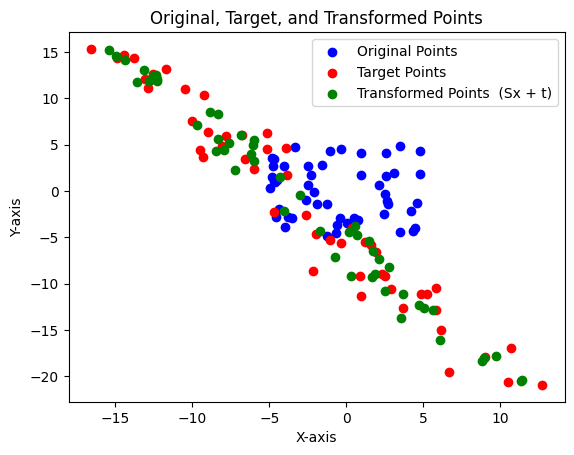

In [11]:
import matplotlib.pyplot as plt
y_hat = np.dot(x, S) + t


plt.scatter(x[:, 0], x[:, 1], color='blue', label='Original Points')
plt.scatter(y[:, 0], y[:, 1], color='red', label='Target Points')
plt.scatter(y_hat[:, 0], y_hat[:, 1], color='green', label='Transformed Points  (Sx + t)')
plt.legend()
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Original, Target, and Transformed Points')
plt.show()

### 1.2.6

Case 0 Homography Matrix H:
[[ 1.00555949e+00  1.61370672e-03 -1.35143989e-01]
 [ 2.56045861e-03  6.22536404e-01 -7.35872070e-01]
 [ 4.51704286e-05  3.59823762e-05  1.00000000e+00]]



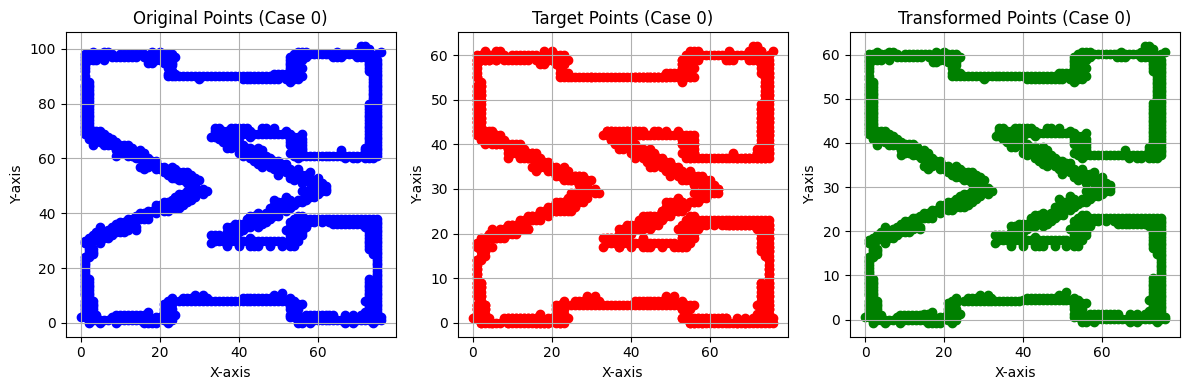

Case 1 Homography Matrix H:
[[ 6.20394776e-01  1.50050345e-03 -6.60977645e-01]
 [ 4.62565656e-05  1.00232229e+00 -4.06369835e-02]
 [ 3.66035139e-07  2.25931463e-05  1.00000000e+00]]



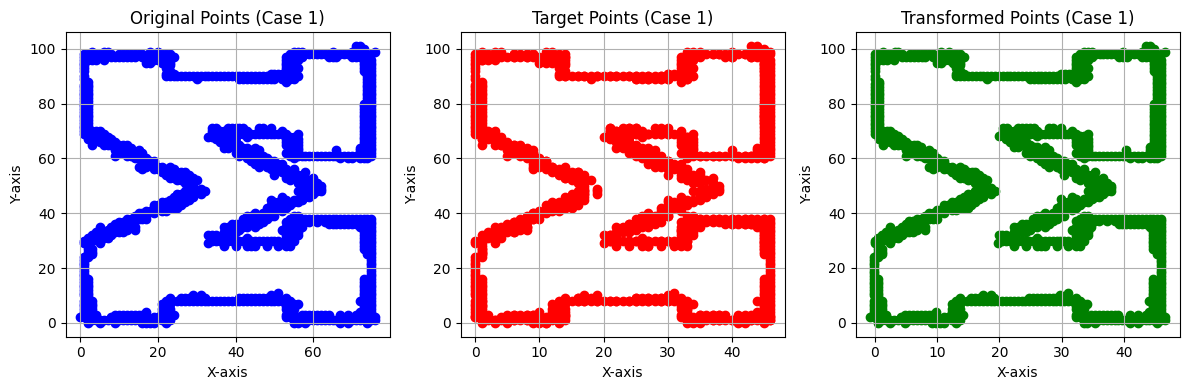

Case 2 Homography Matrix H:
[[ 6.46216419e-01  1.01850154e-02 -1.45233663e+00]
 [ 1.39156925e-02  6.46332905e-01 -1.60285342e+00]
 [ 3.11050183e-04  2.76954685e-04  1.00000000e+00]]



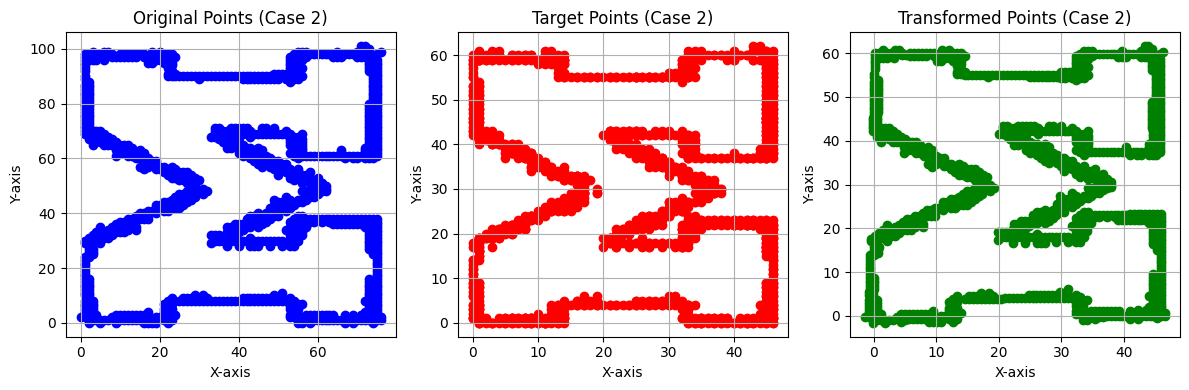

Case 3 Homography Matrix H:
[[ 3.92727662e-14  1.00000000e+00 -4.01982298e-13]
 [ 1.00000000e+00  6.17269379e-16 -1.05152358e-13]
 [ 0.00000000e+00 -9.61481343e-17  1.00000000e+00]]



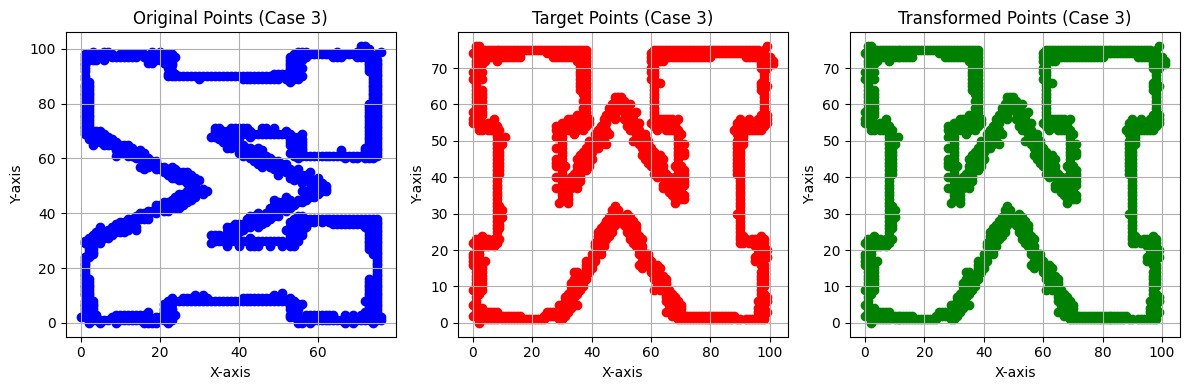

Case 4 Homography Matrix H:
[[-1.00000000e+00  6.59994092e-14  7.60000000e+01]
 [-1.84203522e-13 -1.00000000e+00  1.01000000e+02]
 [-4.53655995e-15  4.64620490e-15  1.00000000e+00]]



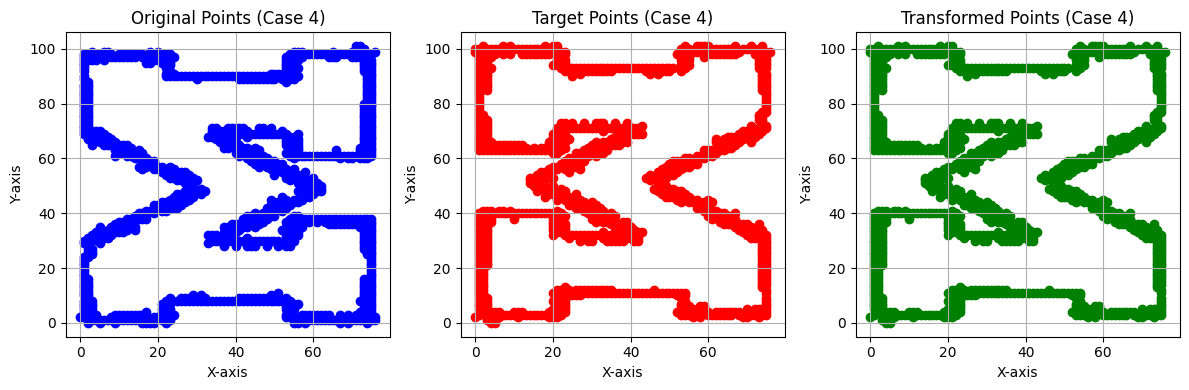

Case 5 Homography Matrix H:
[[ 4.01387046e-01  6.36777993e-01 -1.79445757e+00]
 [ 6.40534201e-01  3.96745666e-01 -1.76059696e+00]
 [ 2.21034153e-04  1.39932850e-04  1.00000000e+00]]



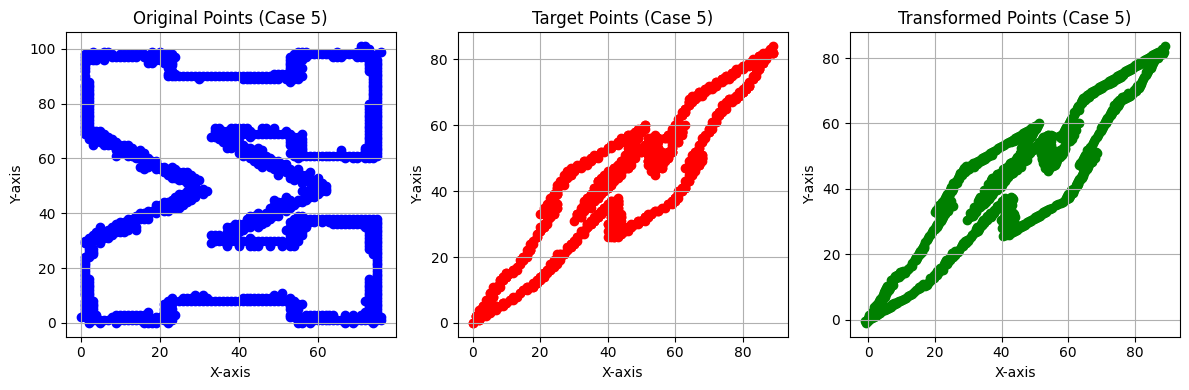

Case 6 Homography Matrix H:
[[ 7.70056604e-01  4.54255201e-02 -6.34808816e-02]
 [-7.87253712e-02  8.63813194e-01  5.49671671e+00]
 [-3.05270237e-04 -6.37121535e-05  1.00000000e+00]]



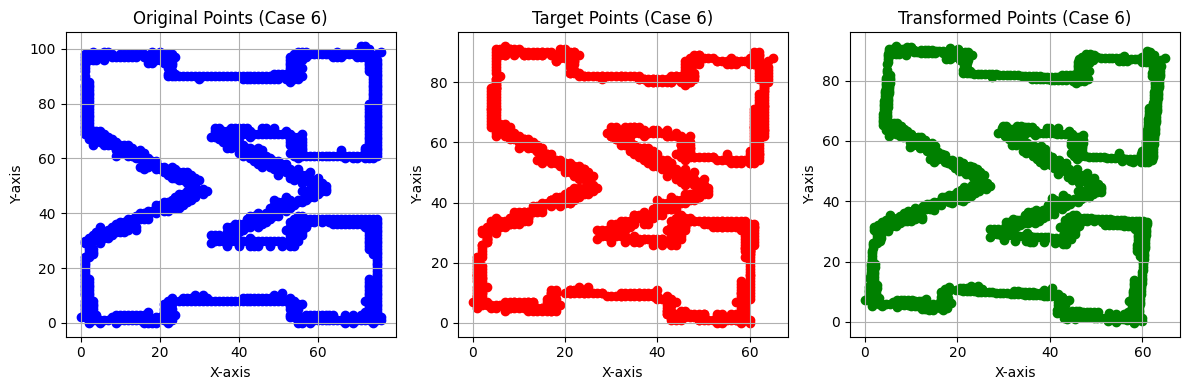

Case 7 Homography Matrix H:
[[ 8.41165566e-01 -4.86333708e-02  4.30457199e+00]
 [-4.77384685e-02  9.86999947e-01  3.56055033e+00]
 [-4.55556648e-04  1.08171485e-04  1.00000000e+00]]



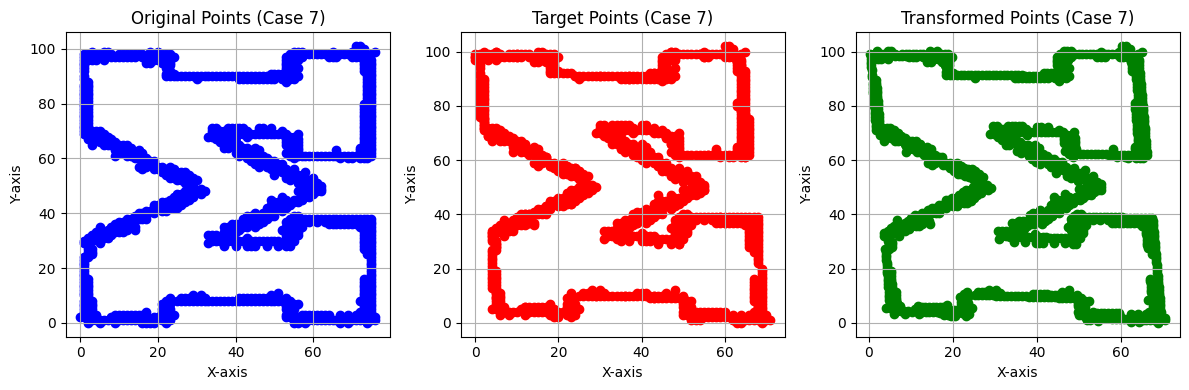

In [14]:
import numpy as np
from numpy.linalg import lstsq

def fit_homography(x, y):
    
    N = x.shape[0]
    A = []

    # Construct the matrix A for the homogeneous system A * h = 0
    for i in range(N):
        x_i, y_i = x[i, 0], x[i, 1]
        x_prime_i, y_prime_i = y[i, 0], y[i, 1]
        
        A.append([-x_i, -y_i, -1, 0, 0, 0, x_i * x_prime_i, y_i * x_prime_i, x_prime_i])
        A.append([0, 0, 0, -x_i, -y_i, -1, x_i * y_prime_i, y_i * y_prime_i, y_prime_i])
    
    A = np.array(A)

    # Solve Ah = 0 using least squares
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    # Normalize H to ensure ||h|| = 1
    H = H / H[-1, -1]

    return H

def apply_homography(H, x):
    
    N = x.shape[0]
    # Convert to homogeneous coordinates by appending a column of ones
    x_homogeneous = np.hstack([x, np.ones((N, 1))])

    y_homogeneous = np.dot(H, x_homogeneous.T).T

    # Convert back to Cartesian coordinates by dividing by the last coordinate
    y_transformed = y_homogeneous[:, :2] / y_homogeneous[:, 2, np.newaxis]

    return y_transformed


for case_num in range(0, 8):
    case_data = np.load(f'C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p1/points_case_{case_num}.npy')  # Replace with the correct path
    
    x = case_data[:, :2]  # Original points
    y = case_data[:, 2:]  # Target points

    H = fit_homography(x, y)

    # Print the resulting homography matrix
    print(f"Case {case_num} Homography Matrix H:\n{H}\n")


    y_transformed = apply_homography(H, x)

    # Plot the original points, target points, and transformed points
    plt.figure(figsize=(12, 4))

    # Subplot 1: Original points (x)
    plt.subplot(1, 3, 1)
    plt.scatter(x[:, 0], x[:, 1], color='blue', label='Original Points (x)')
    plt.title(f'Original Points (Case {case_num})')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True)

    # Subplot 2: Target points (y)
    plt.subplot(1, 3, 2)
    plt.scatter(y[:, 0], y[:, 1], color='red', label='Target Points (y)')
    plt.title(f'Target Points (Case {case_num})')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True)

    # Subplot 3: Transformed points (ŷ = Hx)
    plt.subplot(1, 3, 3)
    plt.scatter(y_transformed[:, 0], y_transformed[:, 1], color='green', label='Transformed Points (Hx)')
    plt.title(f'Transformed Points (Case {case_num})')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True)

    # Show the full figure for the case
    plt.tight_layout()
    plt.show()


### Q 2.1

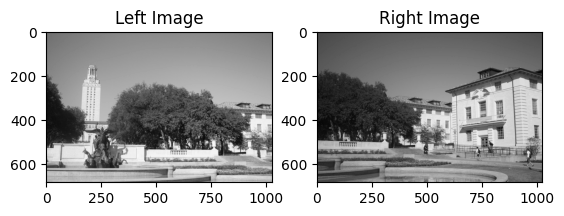

In [15]:
import cv2
import matplotlib.pyplot as plt

# Load the images
img_left = cv2.imread('C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p2/uttower_left.jpg')
img_right = cv2.imread('C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p2/uttower_right.jpg')

# Convert images to grayscale
img_left_gray = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
img_right_gray = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

# Convert to double (normalize)
img_left_gray = img_left_gray.astype('float64') / 255.0
img_right_gray = img_right_gray.astype('float64') / 255.0

# Display grayscale images
plt.subplot(1, 2, 1)
plt.imshow(img_left_gray, cmap='gray')
plt.title("Left Image")

plt.subplot(1, 2, 2)
plt.imshow(img_right_gray, cmap='gray')
plt.title("Right Image")

plt.show()


In [17]:
img_left_gray

array([[0.42352941, 0.42745098, 0.43137255, ..., 0.4745098 , 0.47058824,
        0.46666667],
       [0.42745098, 0.42745098, 0.43137255, ..., 0.47843137, 0.4745098 ,
        0.4745098 ],
       [0.43137255, 0.43529412, 0.43529412, ..., 0.48235294, 0.47843137,
        0.47843137],
       ...,
       [0.6745098 , 0.67843137, 0.70196078, ..., 0.65490196, 0.65098039,
        0.63921569],
       [0.65098039, 0.6627451 , 0.69019608, ..., 0.69803922, 0.69803922,
        0.69019608],
       [0.52156863, 0.54117647, 0.58039216, ..., 0.69019608, 0.69019608,
        0.69019608]])

### Q 2.2

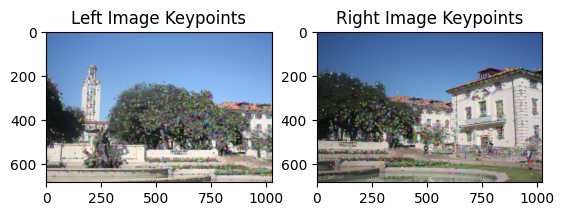

In [18]:
sift = cv2.SIFT_create()

img_left_gray = cv2.normalize(img_left_gray, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')  ## https://stackoverflow.com/questions/50298329/error-5-image-is-empty-or-has-incorrect-depth-cv-8u-in-function-cvsift
img_right_gray = cv2.normalize(img_right_gray, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

# Detect keypoints and compute descriptors
kp_left, desc_left = sift.detectAndCompute(img_left_gray, None)
kp_right, desc_right = sift.detectAndCompute(img_right_gray, None)

# Draw keypoints on the images
img_left_kp = cv2.drawKeypoints(img_left, kp_left, None)
img_right_kp = cv2.drawKeypoints(img_right, kp_right, None)

# Display images with keypoints
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_left_kp, cv2.COLOR_BGR2RGB))
plt.title("Left Image Keypoints")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_right_kp, cv2.COLOR_BGR2RGB))
plt.title("Right Image Keypoints")

plt.show()

### Q 2.3

In [19]:
def compute_distances(desc1, desc2):
    dists = np.zeros((desc1.shape[0], desc2.shape[0]))

    # Use Euclidean distance for example
    for i in range(desc1.shape[0]):
        for j in range(desc2.shape[0]):
            dists[i, j] = np.linalg.norm(desc1[i] - desc2[j])
    
    return dists

pairwise_distances = compute_distances(desc_left, desc_right)

# print("Pairwise distances computed using Euclidean distance",pairwise_distances)

Pairwise distances computed using Euclidean distance


In [20]:
print("Pairwise distances computed using Euclidean distance",pairwise_distances)

Pairwise distances computed using Euclidean distance [[546.65344238 619.24871826 583.60516357 ... 522.36865234 598.44128418
  517.43499756]
 [645.28363037 684.09210205 648.66943359 ... 646.30950928 591.61724854
  534.97290039]
 [603.35150146 594.21710205 537.31555176 ... 567.46276855 527.1574707
  581.91064453]
 ...
 [609.45306396 608.62139893 612.79852295 ... 538.637146   631.91217041
  572.35650635]
 [492.00204468 414.45263672 521.03839111 ... 507.81787109 613.36450195
  600.34741211]
 [520.31719971 590.38208008 475.63537598 ... 515.29119873 549.85998535
  571.89074707]]


### Q 2.4

In [21]:
def select_putative_matches(distances, ratio_threshold=0.75):
    putative_matches = []
    
    for i in range(distances.shape[0]):
        sorted_indices = np.argsort(distances[i])
        nearest_dist = distances[i, sorted_indices[0]]
        second_nearest_dist = distances[i, sorted_indices[1]]
        
        # Ratio test
        if nearest_dist < ratio_threshold * second_nearest_dist:
            putative_matches.append((i, sorted_indices[0]))
    
    return putative_matches

putative_matches = select_putative_matches(pairwise_distances)

print(f"Number of putative matches: {len(putative_matches)}")


Number of putative matches: 1118


### Q 2.5

Number of inliers: 1068


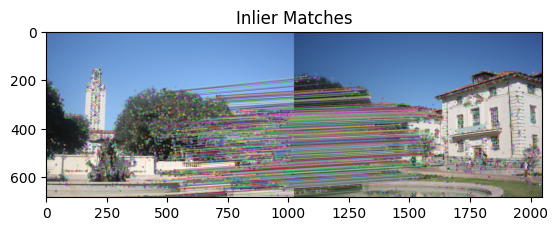

In [31]:
import random


def ransac_homography(matches, kp_left, kp_right, num_iterations=1000, threshold=5):
    best_inliers = []
    best_H = None
    max_inliers = 0

    match_indices = np.arange(len(matches))

    for i in range(num_iterations):
        chosen_indices = np.random.choice(match_indices, 4, replace=False)
        sample_matches = [matches[i] for i in chosen_indices]

        # Get the corresponding points
        pts_left = np.float32([kp_left[m[0]].pt for m in sample_matches])
        pts_right = np.float32([kp_right[m[1]].pt for m in sample_matches])

        H, _ = cv2.findHomography(pts_left, pts_right)

        inliers = []
        for match in matches:
            pt_left = np.append(kp_left[match[0]].pt, 1)
            pt_right = np.append(kp_right[match[1]].pt, 1)
            
            # Transform the left point
            estimated_pt_right = np.dot(H, pt_left)
            estimated_pt_right /= estimated_pt_right[2]  # Normalize

            error = np.linalg.norm(estimated_pt_right[:2] - pt_right[:2])

            if error < threshold:
                inliers.append(match)

        if len(inliers) > max_inliers:
            max_inliers = len(inliers)
            best_inliers = inliers
            best_H = H

    return best_H, best_inliers

H, inliers = ransac_homography(putative_matches, kp_left, kp_right)

print(f"Number of inliers: {len(inliers)}")

inlier_img = cv2.drawMatches(img_left, kp_left, img_right, kp_right, 
                             [cv2.DMatch(m[0], m[1], 0) for m in inliers], None)

plt.imshow(cv2.cvtColor(inlier_img, cv2.COLOR_BGR2RGB))
plt.title("Inlier Matches")
plt.show()


In [33]:
# Calculate average residual for inliers
residuals = []
for match in inliers:
    pt_left = np.append(kp_left[match[0]].pt, 1)
    pt_right = np.append(kp_right[match[1]].pt, 1)

    estimated_pt_right = np.dot(H, pt_left)
    estimated_pt_right /= estimated_pt_right[2]  # Normalize

    # Calculate the squared distance (residual)
    residual = np.linalg.norm(estimated_pt_right[:2] - pt_right[:2]) ** 2
    residuals.append(residual)

average_residual = np.mean(residuals) if residuals else 0
print(f"Average residual for inliers: {average_residual:.4f}")



Average residual for inliers: 1.4648


### Q 2.6

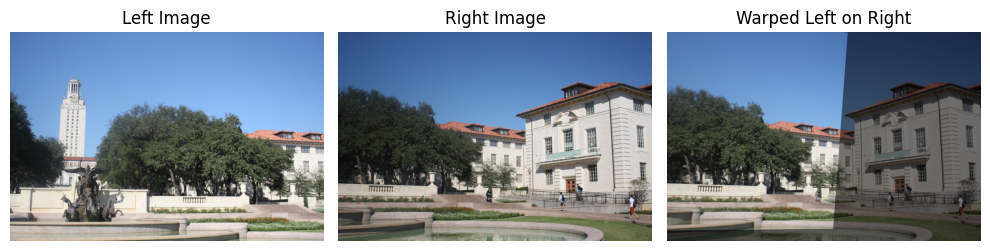

In [34]:
height, width = img_right.shape[:2]

# Warp the left image using the homography matrix
warped_left = cv2.warpPerspective(img_left, H, (width, height))

# Create a mask for the warped image to handle blending
mask = (warped_left > 0).astype(np.uint8)

combined_img = cv2.addWeighted(warped_left, 0.5, img_right, 0.5, 0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
plt.title("Left Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
plt.title("Right Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB))
plt.title("Warped Left on Right")
plt.axis('off')

plt.tight_layout()
plt.show()

### Q 2.7

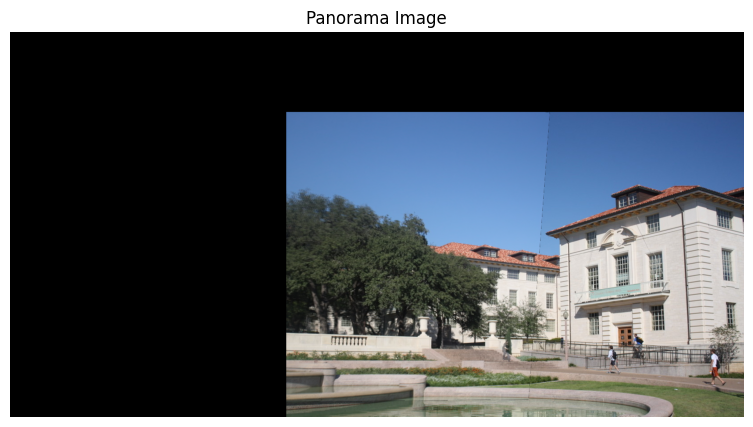

In [45]:
height_right, width_right = img_right.shape[:2]

# Get the corners of the left image after warping
corners_left = np.array([[0, 0], [0, img_left.shape[0]], [img_left.shape[1], 0], [img_left.shape[1], img_left.shape[0]], [1, 1]], dtype=np.float32)
corners_right = np.array([[0, 0], [0, height_right], [width_right, 0], [width_right, height_right], [1, 1]], dtype=np.float32)

# Warp the corners of the left image to find the new bounding box
warped_corners_left = cv2.perspectiveTransform(corners_left[:, :2].reshape(-1, 1, 2), H).reshape(-1, 2)

# Calculate the new bounding box for the panorama
min_x = min(int(np.min(warped_corners_left[:, 0])), 0)
max_x = max(int(np.max(warped_corners_left[:, 0])), width_right)
min_y = min(int(np.min(warped_corners_left[:, 1])), 0)
max_y = max(int(np.max(warped_corners_left[:, 1])), height_right)

width_panorama = int(max_x - min_x)
height_panorama = int(max_y - min_y)

panorama = np.zeros((height_panorama, width_panorama, 3), dtype=np.uint8)

H_translation = np.array([[1, 0, -min_x], [0, 1, -min_y], [0, 0, 1]])  # Translate to positive coordinates
warped_left = cv2.warpPerspective(img_left, H_translation @ H, (width_panorama, height_panorama))

# Place the right image in the panorama
panorama[-min_y:height_right-min_y, -min_x:width_right-min_x] = img_right

# Composite the two images by averaging the overlapping pixels
for y in range(height_panorama):
    for x in range(width_panorama):
        if (warped_left[y, x].any() and panorama[y, x].any()):
            panorama[y, x] = (warped_left[y, x] / 2 + panorama[y, x] / 2).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama Image")
plt.axis('off')
plt.show()

### Q 2.8

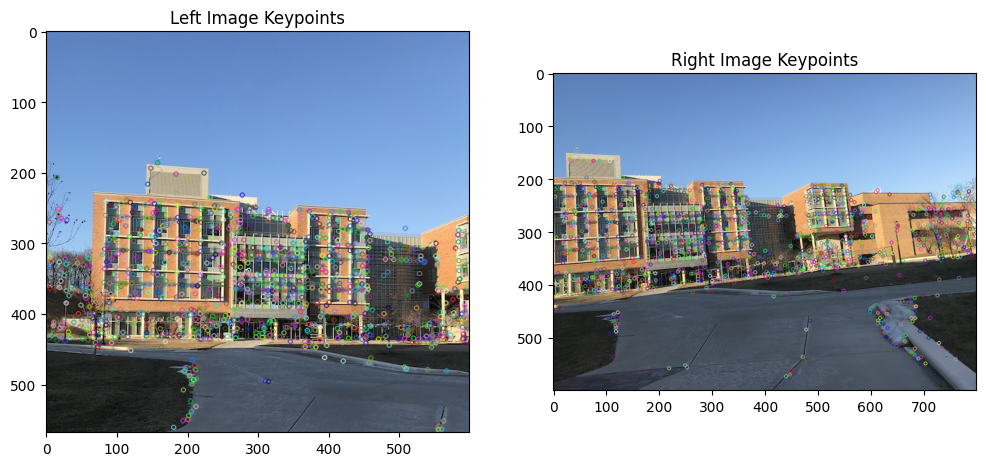

In [46]:
img_left = cv2.imread('C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p2/bbb_left.jpg')
img_right = cv2.imread('C:/Users/vipul/Documents/MSU - MSDS/CSE 803 CV/HW3 (2)/release_starter_files/p2/bbb_right.jpg')

img_left_gray = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
img_right_gray = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
kp_left, desc_left = sift.detectAndCompute(img_left_gray, None)
kp_right, desc_right = sift.detectAndCompute(img_right_gray, None)

# Draw keypoints on the images for visualization
img_left_kp = cv2.drawKeypoints(img_left, kp_left, None)
img_right_kp = cv2.drawKeypoints(img_right, kp_right, None)

# Display images with detected keypoints
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_left_kp, cv2.COLOR_BGR2RGB))
plt.title("Left Image Keypoints")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_right_kp, cv2.COLOR_BGR2RGB))
plt.title("Right Image Keypoints")
plt.show()


In [47]:
pairwise_distances = compute_distances(desc_left, desc_right)
putative_matches = select_putative_matches(pairwise_distances)
print(f"putative matches: {(putative_matches)}")


putative matches: [(112, 1108), (122, 92), (125, 3), (127, 5), (155, 139), (159, 44), (165, 45), (167, 41), (178, 72), (180, 862), (182, 81), (185, 2), (192, 79), (193, 11), (194, 3), (195, 3), (199, 200), (201, 96), (202, 17), (203, 18), (206, 22), (207, 37), (209, 39), (210, 110), (211, 31), (213, 29), (214, 30), (216, 44), (219, 243), (220, 244), (223, 41), (224, 69), (225, 64), (228, 67), (229, 45), (230, 46), (231, 68), (237, 62), (241, 71), (244, 65), (246, 66), (247, 48), (248, 59), (251, 97), (252, 99), (253, 171), (256, 84), (259, 84), (261, 79), (262, 93), (266, 92), (271, 200), (272, 82), (273, 112), (274, 105), (275, 96), (277, 106), (278, 102), (279, 100), (280, 119), (281, 22), (282, 23), (284, 131), (287, 138), (288, 110), (292, 128), (293, 30), (294, 147), (296, 142), (298, 142), (303, 146), (304, 45), (305, 145), (306, 157), (309, 178), (311, 71), (312, 156), (313, 190), (317, 191), (320, 199), (322, 84), (324, 176), (325, 84), (326, 172), (327, 206), (328, 207), (329,

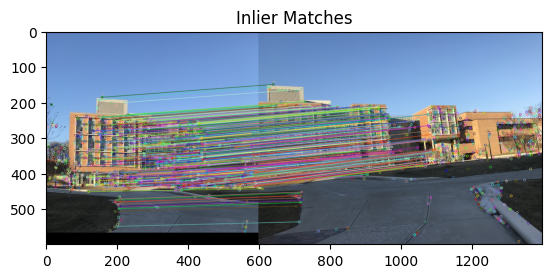

In [48]:
H, inliers = ransac_homography(putative_matches, kp_left, kp_right)
inlier_img = cv2.drawMatches(img_left, kp_left, img_right, kp_right, 
                             [cv2.DMatch(m[0], m[1], 0) for m in inliers], None)

plt.imshow(cv2.cvtColor(inlier_img, cv2.COLOR_BGR2RGB))
plt.title("Inlier Matches")
plt.show()

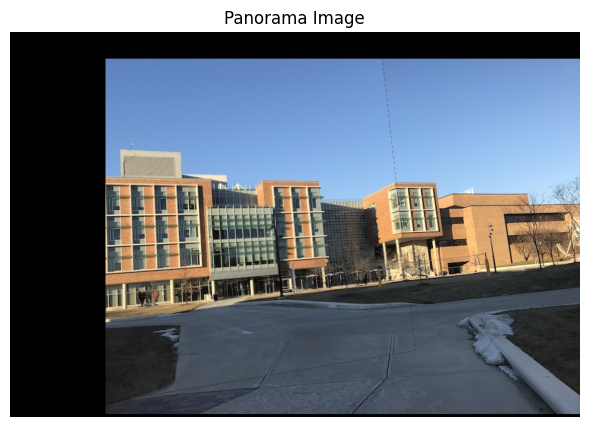

In [54]:
height_right, width_right = img_right.shape[:2]

# Get the corners of the left image after warping
corners_left = np.array([[0, 0], [0, img_left.shape[0]], [img_left.shape[1], 0], [img_left.shape[1], img_left.shape[0]], [1, 1]], dtype=np.float32)
corners_right = np.array([[0, 0], [0, height_right], [width_right, 0], [width_right, height_right], [1, 1]], dtype=np.float32)

# Warp the corners of the left image to find the new bounding box
warped_corners_left = cv2.perspectiveTransform(corners_left[:, :2].reshape(-1, 1, 2), H).reshape(-1, 2)

# Calculate the new bounding box for the panorama
min_x = min(int(np.min(warped_corners_left[:, 0])), 0)
max_x = max(int(np.max(warped_corners_left[:, 0])), width_right)
min_y = min(int(np.min(warped_corners_left[:, 1])), 0)
max_y = max(int(np.max(warped_corners_left[:, 1])), height_right)

width_panorama = int(max_x - min_x)
height_panorama = int(max_y - min_y)

panorama = np.zeros((height_panorama, width_panorama, 3), dtype=np.uint8)

H_translation = np.array([[1, 0, -min_x], [0, 1, -min_y], [0, 0, 1]])  # Translate to positive coordinates
warped_left = cv2.warpPerspective(img_left, H_translation @ H, (width_panorama, height_panorama))

# Place the right image in the panorama
panorama[-min_y:height_right-min_y, -min_x:width_right-min_x] = img_right

# Composite the two images by averaging the overlapping pixels
for y in range(height_panorama):
    for x in range(width_panorama):
        if (warped_left[y, x].any() and panorama[y, x].any()):
            panorama[y, x] = (warped_left[y, x] / 2 + panorama[y, x] / 2).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Panorama Image")
plt.axis('off')
plt.show()

NameError: name 'd' is not defined